In [1]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse


/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/

In [2]:
data_dir = "/allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/BasalGanglia_paper_package/data/xspecies"

work_dir = "/allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/BasalGanglia_paper_package/analysis/neurotransmitter"
os.makedirs(work_dir, exist_ok=True)

In [3]:
adata = sc.read_h5ad(data_dir + "/Consensus_HMBA_basalganglia_AIT_pre-print.h5ad")

In [4]:
adata

AnnData object with n_obs × n_vars = 1896133 × 16630
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'cluster_id', 'cell_type_ontology_term', 'load_id', 'donor_id', 'assay', 'assay_ontology_term_id', 'organism', 'organism_ontology_term_id', 'development_stage', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'brain_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'atac_confidently_mapped_read_pairs', 'atac_fraction_of_genome_in_peaks', 'atac_fraction_of_high_quality_fragments_in_cells', 'atac_fraction_of_high_quality_fragments_overlapping_tss', 'atac_fraction_of_high_quality_fragments_overlapping_peaks', 'atac_fraction_of_transposition_events_in_peaks_in_cells', 'atac_mean_raw_read_pairs_per_cell', 'atac_median_high_quality_fragments_per_cell', 'ata

In [5]:
adata.X

In [6]:
set(adata.obs['organism'])

{'Human', 'Macaque', 'Marmoset'}

In [7]:
adata.X = adata.layers["UMIs"].copy()

sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.log1p(adata)

In [11]:
EXPRESSION_THRESHOLD = 2
CLUSTER_KEY = 'Cluster'

# Define neurotransmitter marker logic (each value is a list of OR-groups; multiple groups imply AND logic)
NEUROTRANSMITTER_MARKERS = {
    "Glut": [["SLC17A6", "SLC17A7", "SLC17A8"]],
    "GABA": [["SLC32A1", "SLC18A2"], ["GAD1", "GAD2", "ALDH1A1"]],
    "Glyc": [["SLC6A5"]],
    "Chol": [["SLC18A3"], ["CHAT"]],
    "Dopa": [["SLC6A3", "SLC18A2"], ["TH", "DDC"]],
    "Sero": [["SLC6A4", "SLC18A2"], ["TPH2"], ["DDC"]],
    "Nora": [["SLC6A2", "SLC18A2"], ["DBH"]],
    "Hist": [["SLC18A2"], ["HDC"]],
}

# ---------- 0) Utility: species from cluster prefix (no behavior change) ----------
def _species_from_cluster_name(name: str) -> str:
    """Infer species from a cluster name like 'Human-101' -> 'Human'."""
    try:
        return name.split("-", 1)[0]
    except Exception:
        return "Unknown"

# ---------- 1) Missing-gene report (reporting only, no logic change) ----------
def report_missing_genes(var_names, marker_logic):
    """
    Print which genes in each OR-group are absent from var_names.
    This is informational only and DOES NOT change your marker lists or logic.
    """
    varset = set(var_names)
    missing_any = False
    print("\n[Info] Checking missing genes against adata.var_names ...")
    for nt, rules in marker_logic.items():
        for i, or_group in enumerate(rules, start=1):
            missing = [g for g in or_group if g not in varset]
            if missing:
                missing_any = True
                print(f"  - {nt} | OR-group {i}: missing -> {', '.join(missing)}")
    if not missing_any:
        print("  - No missing genes found for any OR-group.")
    print("[Info] Missing-gene check complete.\n")

# Call the reporter (no side effects on your logic)
report_missing_genes(adata.var_names, NEUROTRANSMITTER_MARKERS)

# ---------- 2) Prepare expression matrix for available marker genes ----------
# Flatten all genes used in the marker logic (keep your exact gene list)
all_marker_genes = sorted({gene for groups in NEUROTRANSMITTER_MARKERS.values()
                           for group in groups for gene in group})

# Keep only those actually present in this adata (same as your code)
genes_available = [g for g in all_marker_genes if g in adata.var_names]
gene_indices = [adata.var_names.get_loc(g) for g in genes_available]

# Slice .X for marker genes only; keep your toarray behavior on the slice
X_slice = adata.X[:, gene_indices]
if sparse.issparse(X_slice):
    X_slice = X_slice.toarray()

expr_df = pd.DataFrame(
    X_slice,
    columns=genes_available,
    index=adata.obs_names
)
expr_df[CLUSTER_KEY] = adata.obs[CLUSTER_KEY].values

# ---------- 3) Median per cluster ----------
cluster_medians = expr_df.groupby(CLUSTER_KEY).median()

# ---------- 4) AND-of-OR logic ----------
def check_nt_identity(row, marker_logic, threshold=3.0):
    """
    Keep your original semantics:
    - For each neurotransmitter nt:
        - Every OR-group in its rules must be satisfied (AND across groups),
        - An OR-group is satisfied if ANY gene in that group is > threshold.
    """
    results = []
    for nt, rules in marker_logic.items():
        satisfied = True
        for or_group in rules:
            if not any((gene in row.index and row[gene] > threshold) for gene in or_group):
                satisfied = False
                break
        if satisfied:
            results.append(nt)
    return results

nt_identity = cluster_medians.apply(
    lambda row: check_nt_identity(row, NEUROTRANSMITTER_MARKERS, threshold=EXPRESSION_THRESHOLD),
    axis=1
)

# ---------- 5) Convert to boolean matrix ----------
nt_identity_bool_df = pd.DataFrame(False, index=nt_identity.index, columns=NEUROTRANSMITTER_MARKERS.keys())
for cluster, matched_types in nt_identity.items():
    for nt in matched_types:
        nt_identity_bool_df.loc[cluster, nt] = True

# Add 'cluster' (as you did) and NEW 'species' parsed from prefix (just for convenience in Excel)
nt_identity_bool_df.insert(0, 'cluster', nt_identity_bool_df.index)
nt_identity_bool_df.insert(0, 'species', nt_identity_bool_df['cluster'].astype(str).map(_species_from_cluster_name))

# ---------- 6) Save combined CSV (single table for all clusters; you can sort in Excel) ----------
out_csv = os.path.join(
    work_dir,
    f"ALL_BG_neurotransmitter_identity_by_cluster_th_{EXPRESSION_THRESHOLD}.csv"
)
nt_identity_bool_df.to_csv(out_csv, index=False)

print("[Done] Wrote:", out_csv)
print(nt_identity_bool_df.head())



[Info] Checking missing genes against adata.var_names ...
  - No missing genes found for any OR-group.
[Info] Missing-gene check complete.

[Done] Wrote: /allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/BasalGanglia_paper_package/analysis/neurotransmitter/ALL_BG_neurotransmitter_identity_by_cluster_th_2.csv
        species  cluster   Glut   GABA   Glyc   Chol   Dopa   Sero   Nora  \
Cluster                                                                     
Human-1   Human  Human-1  False  False  False  False  False  False  False   
Human-2   Human  Human-2  False  False  False  False  False  False  False   
Human-3   Human  Human-3  False  False  False  False  False  False  False   
Human-4   Human  Human-4  False  False  False  False  False  False  False   
Human-5   Human  Human-5  False  False  False  False  False  False  False   

          Hist  
Cluster         
Human-1  False  
Human-2  False  
Human-3  False  
Human-4  False  
Human-5  False  


In [ ]:
# th:1 331/1435
# th: 1.5, 329/1435
# th:2 326/1435

[Saved] /allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/BasalGanglia_paper_package/analysis/neurotransmitter/Human_neurotransmitter_upset.pdf
[Saved] /allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/BasalGanglia_paper_package/analysis/neurotransmitter/Macaque_neurotransmitter_upset.pdf
[Saved] /allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/BasalGanglia_paper_package/analysis/neurotransmitter/Marmoset_neurotransmitter_upset.pdf


<Figure size 800x400 with 0 Axes>

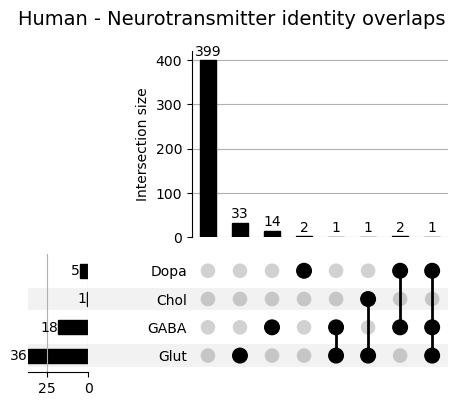

<Figure size 800x400 with 0 Axes>

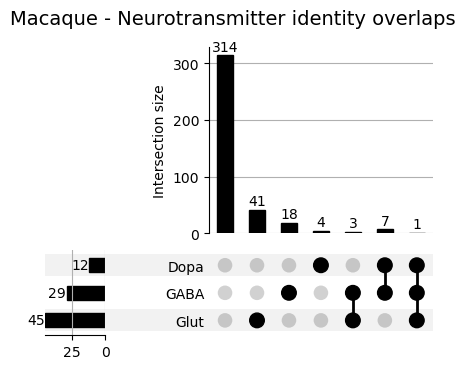

<Figure size 800x400 with 0 Axes>

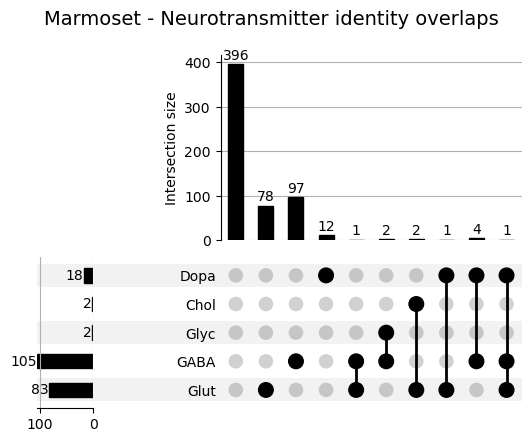

In [13]:
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_indicators

#th_2 now!
# columns: ['species', 'cluster', 'Glut', 'GABA', 'Glyc', 'Chol', 'Dopa', 'Sero', 'Nora', 'Hist']

# ensure -> True/False
nt_cols = [c for c in nt_identity_bool_df.columns if c not in ['species', 'cluster']]
nt_identity_bool_df[nt_cols] = nt_identity_bool_df[nt_cols].astype(bool)


def plot_upset_per_species(df: pd.DataFrame, species: str, outdir: str = None):
    """
    Draw an UpSet plot showing overlap of neurotransmitter identities for one species.
    """
    sub = df[df['species'] == species]
    if sub.empty:
        print(f"[Warning] No data for {species}")
        return
    

    upset_data = from_indicators(nt_cols, sub)
    
    # create UpSet plot
    plt.figure(figsize=(8, 4))
    upset = UpSet(
        upset_data,
        subset_size='count',
        sort_by='degree',
        sort_categories_by=None,
        show_counts=True,
        element_size=30
    )
    upset.plot()
    plt.suptitle(f"{species} - Neurotransmitter identity overlaps", fontsize=14)
    
    # save
    if outdir:
        outfile = f"{outdir}/{species}_neurotransmitter_upset.pdf"
        plt.savefig(outfile, bbox_inches="tight")
        print(f"[Saved] {outfile}")
    else:
        plt.show()

# --- draw it per species ---
for sp in nt_identity_bool_df['species'].unique():
    plot_upset_per_species(nt_identity_bool_df, sp, outdir=work_dir)


### not median > th, but proportions

In [14]:
# --- New thresholds for fraction-based rule ---
EXPRESSION_THRESHOLD = 3.0   # per-cell expression cut (e.g., log1p(CPM) > 3)
FRACTION_THRESHOLD   = 0.20  # at least 20% cells in a cluster exceed the expression cut

# --- Build boolean matrix: cell × gene, True if expression > EXPRESSION_THRESHOLD ---
from scipy import sparse
import numpy as np
import pandas as pd

# Choose the source matrix for expression. If you stored logCPM in a layer, prefer it:
# X_base = adata.layers["logCPM"][:, gene_indices]  # <- if you created this earlier
X_base = adata.X[:, gene_indices]                    # <- otherwise use .X as you are doing now

if sparse.issparse(X_base):
    X_bool = (X_base > EXPRESSION_THRESHOLD).astype(np.uint8)  # sparse OK; convert to 0/1 later
    X_bool = X_bool.A  # densify the slice only (n_cells × n_genes)
else:
    X_bool = (np.asarray(X_base) > EXPRESSION_THRESHOLD).astype(np.uint8)

# --- Map clusters to category codes for fast grouping ---
clusters = adata.obs[CLUSTER_KEY].astype('category')
codes    = clusters.cat.codes.to_numpy()          # shape (n_cells,)
cats     = clusters.cat.categories
n_clusters, n_genes = len(cats), X_bool.shape[1]

# --- Compute per-cluster fraction of cells above threshold for each gene ---
# counts per cluster
counts = np.bincount(codes, minlength=n_clusters).astype(np.float32)  # (#cells in cluster)

# sums per cluster for each gene (loop over 20–50 genes is fine and fast)
frac_arr = np.empty((n_clusters, n_genes), dtype=np.float32)
for j in range(n_genes):
    sums_j = np.bincount(codes, weights=X_bool[:, j].astype(np.float32), minlength=n_clusters)
    # avoid division by zero
    frac_arr[:, j] = np.divide(sums_j, counts, out=np.zeros_like(sums_j, dtype=np.float32), where=counts > 0)

# Wrap into DataFrame indexed by cluster, columns = genes_available
frac_df = pd.DataFrame(frac_arr, index=cats, columns=genes_available)

# --- AND-of-OR logic now uses FRACTION_THRESHOLD on the per-cluster fractions ---
def check_nt_identity_fraction(row_frac: pd.Series, marker_logic: dict,
                               frac_cut: float = FRACTION_THRESHOLD) -> list:
    """
    For each neurotransmitter class:
      - AND across OR-groups,
      - each OR-group passes if ANY gene in that group has fraction >= frac_cut.
    """
    matched = []
    row_idx = set(row_frac.index)
    for nt, rules in marker_logic.items():
        ok = True
        for or_group in rules:
            group_pass = any((g in row_idx) and (row_frac[g] >= frac_cut) for g in or_group)
            if not group_pass:
                ok = False
                break
        if ok:
            matched.append(nt)
    return matched

nt_identity = frac_df.apply(
    lambda r: check_nt_identity_fraction(r, NEUROTRANSMITTER_MARKERS, frac_cut=FRACTION_THRESHOLD),
    axis=1
)

# --- Convert to boolean matrix (unchanged) ---
nt_identity_bool_df = pd.DataFrame(False, index=nt_identity.index, columns=NEUROTRANSMITTER_MARKERS.keys())
for cluster, matched_types in nt_identity.items():
    for nt in matched_types:
        nt_identity_bool_df.loc[cluster, nt] = True

# keep your convenience columns
nt_identity_bool_df.insert(0, 'cluster', nt_identity_bool_df.index)
nt_identity_bool_df.insert(0, 'species', nt_identity_bool_df['cluster'].astype(str).map(_species_from_cluster_name))

# save (unchanged)
out_csv = os.path.join(work_dir, f"ALL_BG_neurotransmitter_identity_by_cluster_frac{FRACTION_THRESHOLD}_expr{EXPRESSION_THRESHOLD}.csv")
nt_identity_bool_df.to_csv(out_csv, index=False)

print("[Done] Wrote:", out_csv)
print(nt_identity_bool_df.head())

[Done] Wrote: /allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/BasalGanglia_paper_package/analysis/neurotransmitter/ALL_BG_neurotransmitter_identity_by_cluster_frac0.2_expr3.0.csv
        species  cluster   Glut   GABA   Glyc   Chol   Dopa   Sero   Nora  \
Human-1   Human  Human-1  False  False  False  False  False  False  False   
Human-2   Human  Human-2  False  False  False  False  False  False  False   
Human-3   Human  Human-3  False  False  False  False  False  False  False   
Human-4   Human  Human-4  False  False  False  False  False  False  False   
Human-5   Human  Human-5  False  False  False  False  False  False  False   

          Hist  
Human-1  False  
Human-2  False  
Human-3  False  
Human-4  False  
Human-5  False  


[Saved] /allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/BasalGanglia_paper_package/analysis/neurotransmitter/Human_neurotransmitter_upset_frac0.2_expr3.0.pdf
[Saved] /allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/BasalGanglia_paper_package/analysis/neurotransmitter/Macaque_neurotransmitter_upset_frac0.2_expr3.0.pdf
[Saved] /allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/BasalGanglia_paper_package/analysis/neurotransmitter/Marmoset_neurotransmitter_upset_frac0.2_expr3.0.pdf


<Figure size 800x400 with 0 Axes>

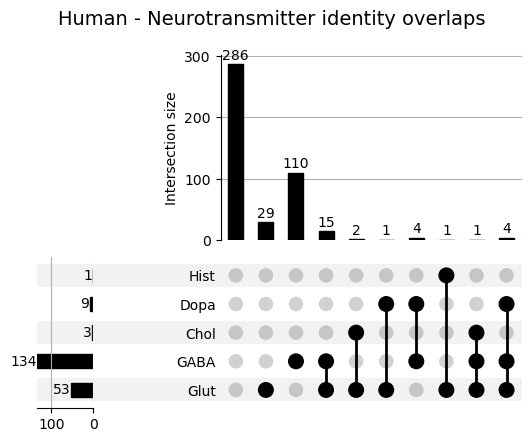

<Figure size 800x400 with 0 Axes>

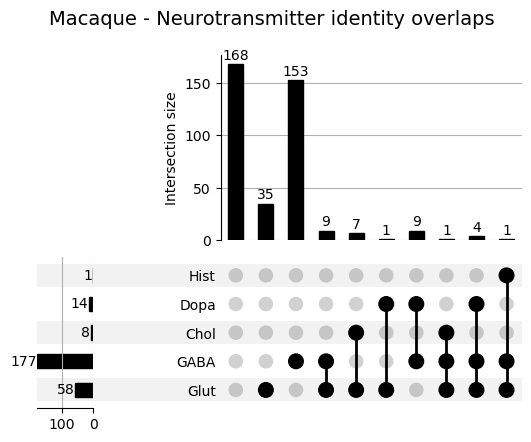

<Figure size 800x400 with 0 Axes>

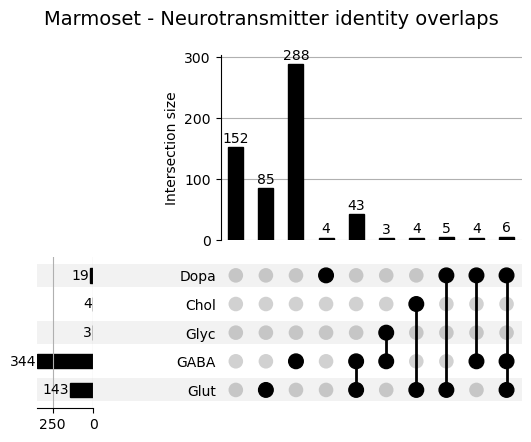

In [15]:
# columns: ['species', 'cluster', 'Glut', 'GABA', 'Glyc', 'Chol', 'Dopa', 'Sero', 'Nora', 'Hist']

# ensure -> True/False
nt_cols = [c for c in nt_identity_bool_df.columns if c not in ['species', 'cluster']]
nt_identity_bool_df[nt_cols] = nt_identity_bool_df[nt_cols].astype(bool)


def plot_upset_per_species(df: pd.DataFrame, species: str, outdir: str = None):
    """
    Draw an UpSet plot showing overlap of neurotransmitter identities for one species.
    """
    sub = df[df['species'] == species]
    if sub.empty:
        print(f"[Warning] No data for {species}")
        return
    

    upset_data = from_indicators(nt_cols, sub)
    
    # create UpSet plot
    plt.figure(figsize=(8, 4))
    upset = UpSet(
        upset_data,
        subset_size='count',
        sort_by='degree',
        sort_categories_by=None,
        show_counts=True,
        element_size=30
    )
    upset.plot()
    plt.suptitle(f"{species} - Neurotransmitter identity overlaps", fontsize=14)
    
    # save
    if outdir:
        outfile = f"{outdir}/{species}_neurotransmitter_upset_frac{FRACTION_THRESHOLD}_expr{EXPRESSION_THRESHOLD}.pdf"
        plt.savefig(outfile, bbox_inches="tight")
        print(f"[Saved] {outfile}")
    else:
        plt.show()

# --- draw it per species ---
for sp in nt_identity_bool_df['species'].unique():
    plot_upset_per_species(nt_identity_bool_df, sp, outdir=work_dir)


In [16]:
del adata.layers['UMIs']

In [20]:
adata.write_h5ad(work_dir + "/temp_consensus_preprint_3species_adata_withlogCPM_X.h5ad")

In [ ]:
### some stat

In [19]:
os.getcwd()

'/home/yuanyuan.fu/yyfu/yyf_scripts/HMBA_hu_all/scripts_for_atlas'

In [22]:
adata.obs.loc[adata.obs['Neighborhood'].isin(["Nonneuron"]), 'Cluster'].nunique()

295

In [23]:
1435-295

1140

In [24]:
adata.obs.loc[adata.obs['Neighborhood'].isin(["Nonneuron"])].groupby('organism')['Cluster'].nunique()


organism
Human       114
Macaque      79
Marmoset    102
Name: Cluster, dtype: int64